# 03 — Bloch bands, OBC spectrum, and finite-size scaling

The bulk bands are `E(k) = -i*gamma/2 ± sqrt(|q|^2-(gamma/2)^2)` (closed form).
The finite-size scan uses a **parity-safe central A-site** bulk reference; the
v1 sublattice-parity artifact (a spurious `N=15` spike) is gone, and both the
enhancement and the edge weight converge smoothly.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo import plotting as P
cfg = nt.load_all(config_dir="../config"); p = nt.get_physics_params(cfg)
from pathlib import Path
def figdir(key): return Path("..") / nt.get_figure_dir(cfg, key)
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}, "
      f"|nu|={nt.topological_invariant(p['t1'], p['t2'])}")

t1=0.8, t2=1.2, gamma=0.3, N=20, |nu|=1


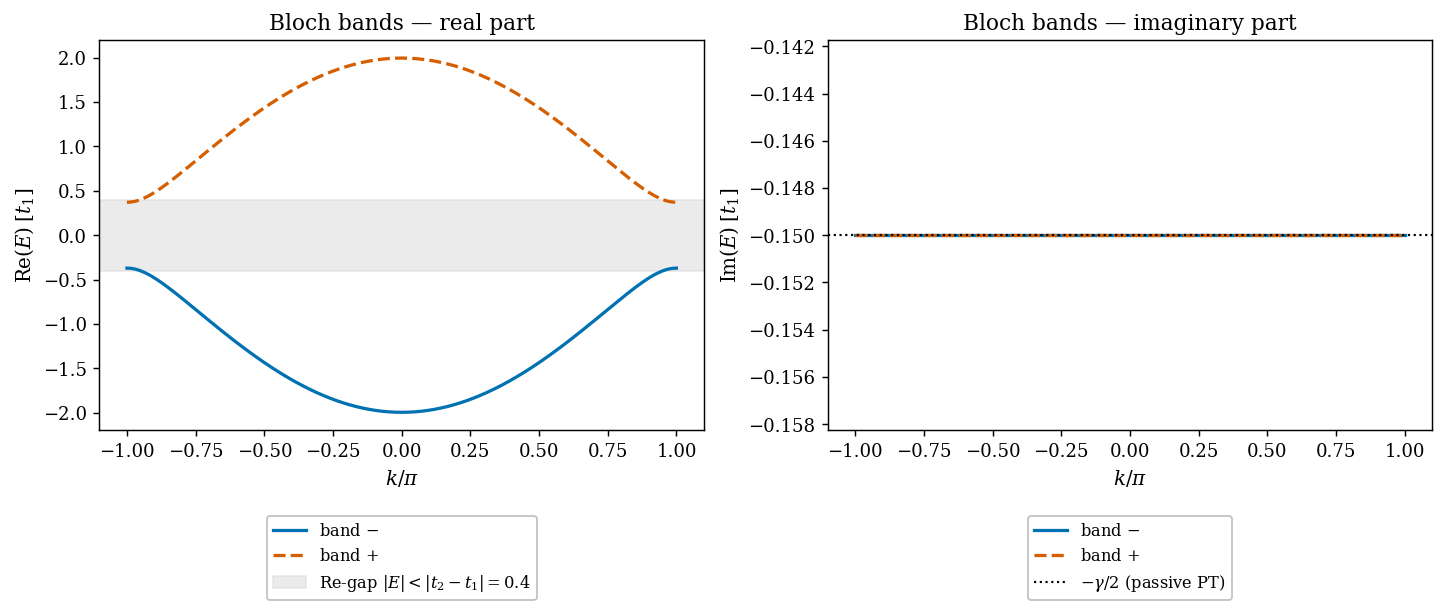

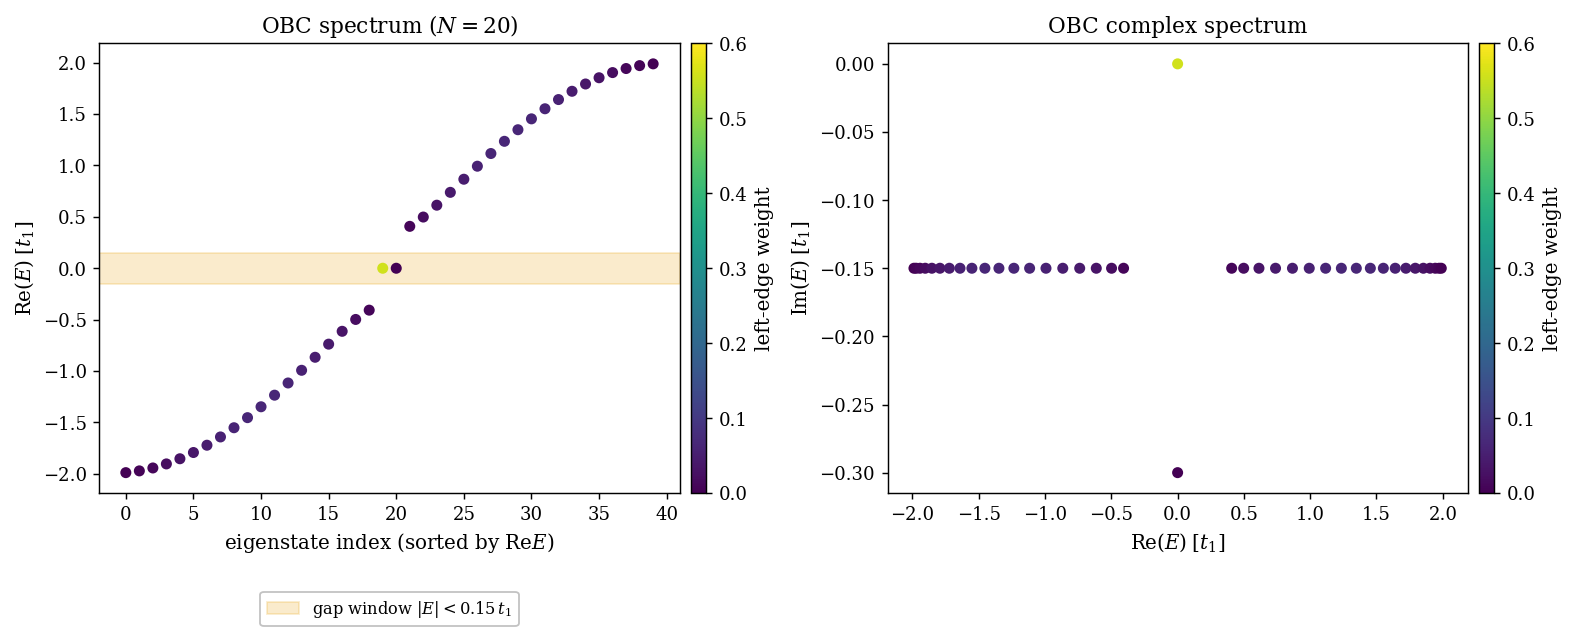

enh(N) = [4.67, 9.43, 10.49, 11.14, 11.25, 11.25, 11.25]
W0(N)  = [0.6726, 0.5656, 0.5579, 0.5556, 0.5556, 0.5556, 0.5556]


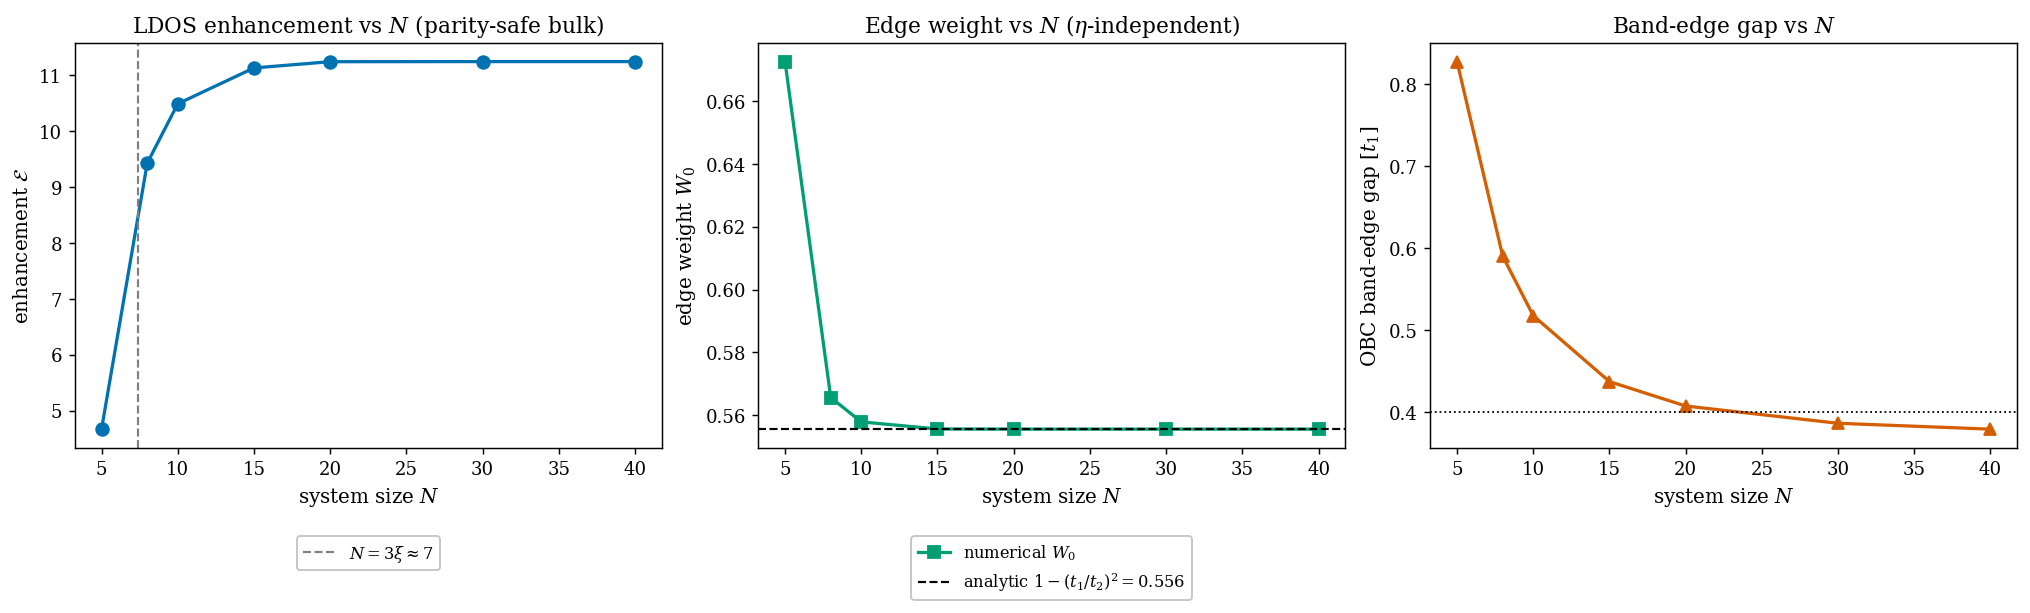

In [2]:
k, bands = nt.compute_bloch_bands(p["t1"], p["t2"], p["gamma"])
fig, _ = P.plot_bloch_bands(k, bands, p["gamma"], p["t1"], p["t2"])
P.save_fig(fig, figdir("03_numerical_bandstructures"), "01_bloch_bands"); plt.show()

H = nt.build_ssh(p["N"], p["t1"], p["t2"], p["gamma"])
evals, evecs = nt.diagonalize(H); lw, _ = nt.edge_localization_weights(evecs)
fig, _ = P.plot_obc_spectrum(evals, lw, p["N"], p["gap_hw"])
P.save_fig(fig, figdir("03_numerical_bandstructures"), "02_obc_spectrum"); plt.show()

gap = np.linspace(-p["gap_hw"], p["gap_hw"], 121)
fs = nt.finite_size_convergence(p["t1"], p["t2"], p["gamma"], p["N_vals_fs"], gap, p["eta"])
print("enh(N) =", [round(x, 2) for x in fs["enhancement"]])
print("W0(N)  =", [round(x, 4) for x in fs["edge_weight"]])
fig, _ = P.plot_finite_size(fs["N_vals"], fs["enhancement"], fs["edge_weight"],
                            fs["gap_obc"], nt.localization_length(p["t1"], p["t2"]),
                            nt.analytic_edge_weight(p["t1"], p["t2"]))
P.save_fig(fig, figdir("03_numerical_bandstructures"), "03_finite_size"); plt.show()